In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('results.csv')

# Clean column names just in case
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)

   name year-month  avg_monthly_pct_change
0  AAPL    2025-12               -0.002209
1  AAPL    2026-01               -0.215004
2  AAPL    2026-02               -0.005960
3  AAPL    2026-03               -0.141364
4  AAPL    2026-04                0.285616
Index(['name', 'year-month', 'avg_monthly_pct_change'], dtype='object')


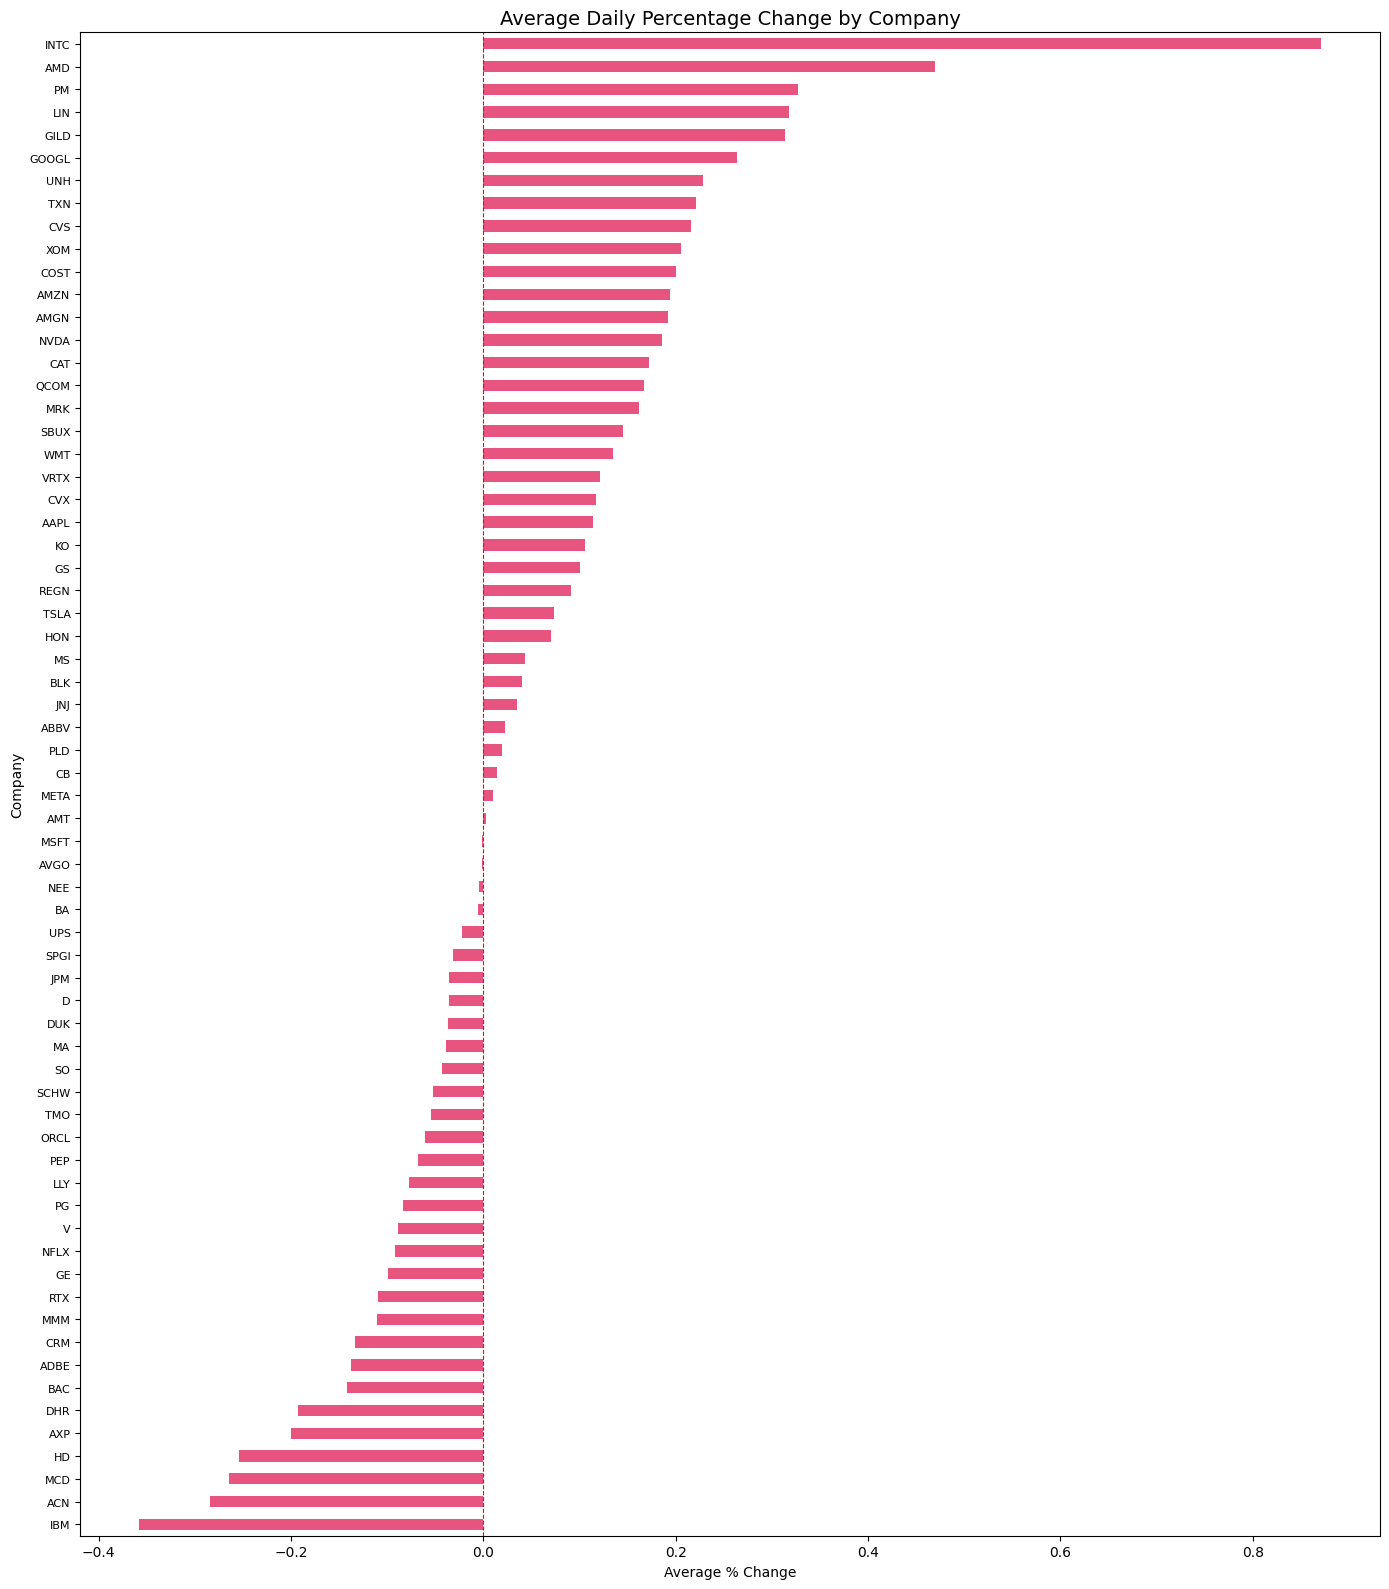

In [3]:
# Chart 1: Rank companies by average daily percentage change
avg_by_company = df.groupby('name')['avg_monthly_pct_change'].mean().sort_values()

plt.figure(figsize=(14, 16))
avg_by_company.plot(kind='barh', color='#E75480')
plt.title('Average Daily Percentage Change by Company', fontsize=14)
plt.xlabel('Average % Change')
plt.ylabel('Company')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('chart1_ranking.png', dpi=150)
plt.show()

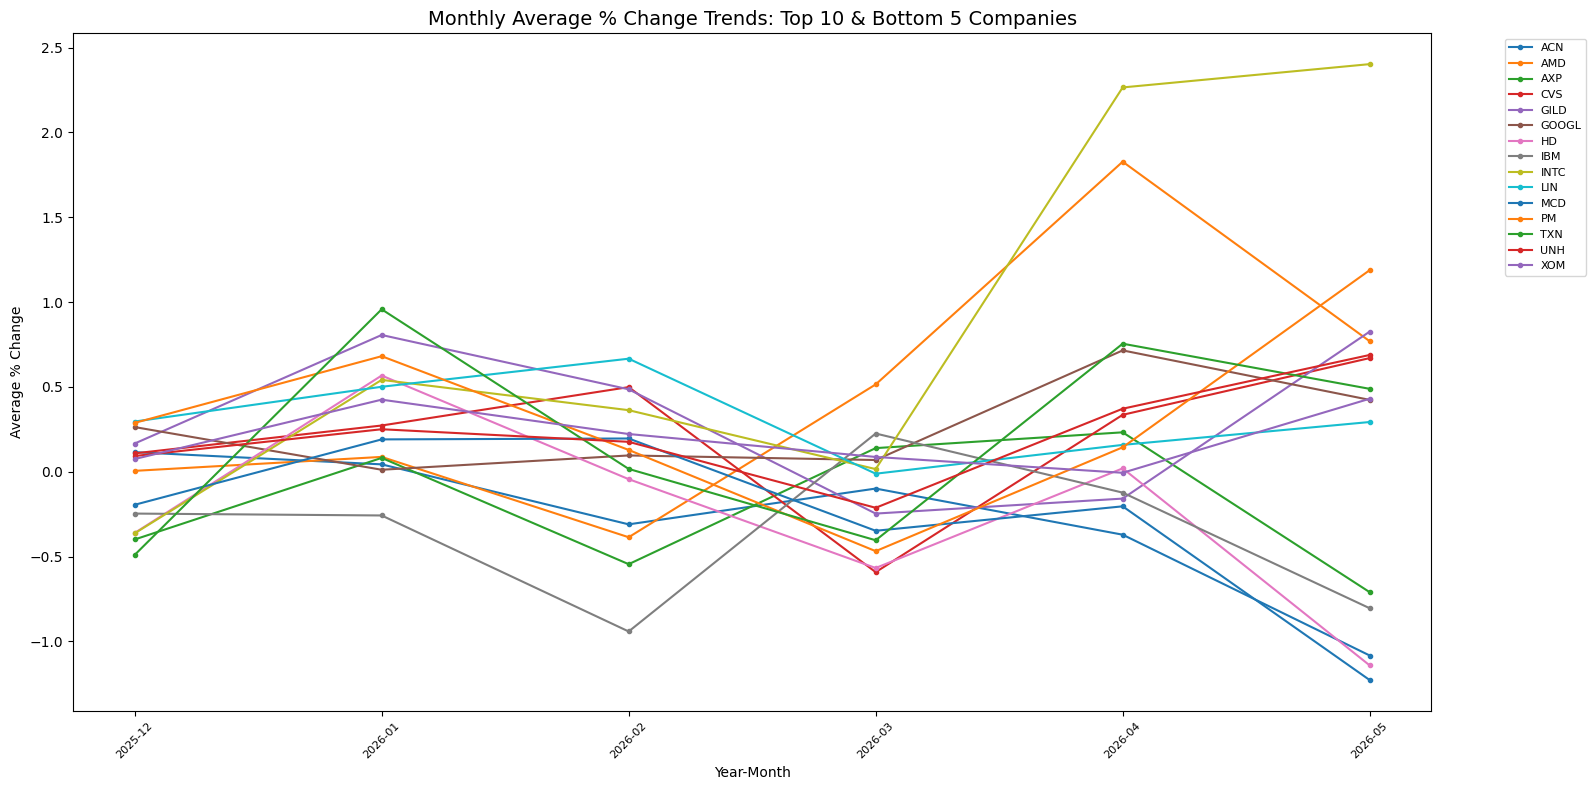

In [7]:
# Chart 2: Monthly trends for top 10 and bottom 5 companies
avg_by_company = df.groupby('name')['avg_monthly_pct_change'].mean().sort_values()
selected = list(avg_by_company.head(5).index) + list(avg_by_company.tail(10).index)

filtered_df = df[df['name'].isin(selected)]
pivot_df = filtered_df.pivot_table(index='year-month', columns='name', values='avg_monthly_pct_change')

plt.figure(figsize=(16, 8))
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], linewidth=1.5, marker='o', markersize=3, label=column)

plt.title('Monthly Average % Change Trends: Top 10 & Bottom 5 Companies', fontsize=14)
plt.xlabel('Year-Month')
plt.ylabel('Average % Change')
plt.xticks(rotation=45, fontsize=8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('chart2_monthly_trends.png', dpi=150)
plt.show()